# Config

## Imports

In [1]:
import logging

logging.basicConfig(
    level=logging.ERROR,
    format="%(asctime)s [%(levelname)s] %(module)s.%(funcName)s(): %(message)s"
)
logger = logging.getLogger(__name__)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from typing import Optional, List

from fjsspw_solver import (
    Individual,
    Encoding,
)
from fjsspw_solver.genetic_algorithm import (
    Method,
    MethodParams,
)
from fjsspw_solver.operators import (
    Selections,
    Crossovers,
    Mutations,
)
from fjsspw_solver.plotting import (
    plot_fjsspw_gantt,
    plot_learning_progress,
)

from util.benchmark_parser import WorkerBenchmarkParser
from util.uncertainty import create_uncertainty_vector
from util.graph import Graph

PROD = False

## Instance setup

In [2]:
parser = WorkerBenchmarkParser()
instance_name = 'Fattahi10.fjs'
encoding = parser.parse_benchmark(f'instances/Example_Instances_FJSSP-WF/{instance_name}')

In [3]:
encoding = Encoding(encoding.durations(), encoding.job_sequence())

method_params = MethodParams(
    generations=10,
    population_size=10,
    selection=Selections.ROULETTE,
    crossover=Crossovers.POX,
    mutation=Mutations.GENE_SWAP,
    fitness_fun_evals_per_indv=3,
    instance_name=instance_name,
)

uncertainty_parameters = create_uncertainty_vector(encoding.n_operations(), factor=10.0, offset=1.0)

In [4]:
def uncertain_eval_function(indv: Individual, iters: int = 1) -> List|float:
    _, machines, workers, start_times, end_times = indv.get_representation()
    logger.debug(f"machines={machines}"
                 f", workers={workers}"
                 f", job_sequence={encoding.get_job_sequence()}"
                 f", start_times={start_times}"
                 f", end_times={end_times}")
    fitnesses = [0] * iters
    for i in range(iters):
        g = Graph(start_times, end_times, machines, workers, encoding.get_job_sequence())
        g.simulate(encoding.get_durations(), uncertainty_parameters, processing_times=True)
        fitnesses[i] = max(g.e)
    return fitnesses if iters > 1 else fitnesses[0]

# Sanity check

## Run method

In [5]:
logger.info("Init method")
method = Method(method_params, encoding, uncertain_eval_function)
logger.info("Finish init method")

AttributeError: Selected MutationParams (MUTATION_PARAMS) doesn't exist

In [ ]:
best_indv = method.solve()

## Evaluate

In [ ]:
sequence, machines, workers, start_times, end_times = best_indv.get_representation()
sequence, machines, workers, start_times, end_times

([3, 1, 2, 2, 0, 0, 3, 3, 1, 1, 0, 2],
 [0, 1, 3, 2, 1, 4, 0, 2, 4, 1, 4, 3],
 [3, 5, 3, 2, 4, 5, 3, 2, 6, 1, 1, 2],
 [94, 253, 466, 0, 142, 374, 0, 142, 560, 0, 71, 332],
 [253, 374, 619, 142, 202, 560, 94, 332, 655, 71, 248, 466])

In [ ]:
if PROD:
    assert len(sequence) > 0, "The sequence should not be empty."
    assert len(machines) > 0, "The number of machines should not be empty."
    assert len(workers) > 0, "The number of workers should not be empty."
    assert len(start_times) > 0, "The number of start_times should not be empty."
    assert len(end_times) > 0, "The number of end_times should not be empty."

In [ ]:
# start_times, machines, workers = evaluation.translate(sequence, machines, workers, encoding.get_durations()) # necessary because the solver does not provide the start times of the schedule
# c = evaluation.makespan(start_times, machines, workers, encoding.get_durations())
c = best_indv.get_internal_fitness()
robust_c = uncertain_eval_function(best_indv)
print(f'Makespan: {c}')
print(f'Robust makespan: {robust_c}')

Makespan: 655
Robust makespan: 1360.1611146255402


## Plot results

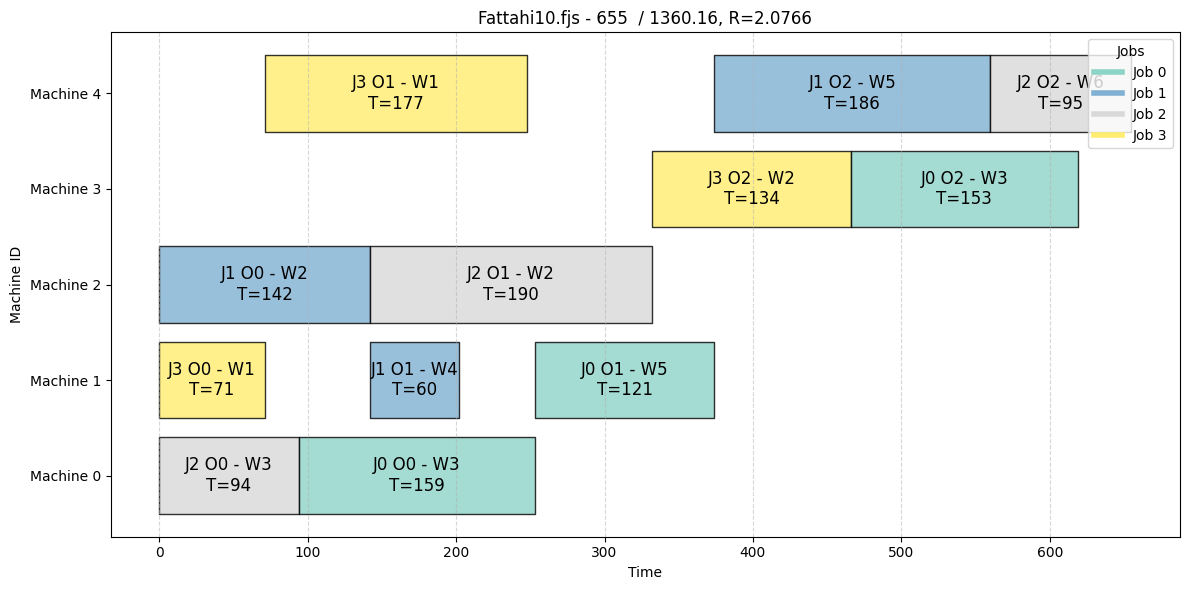

In [ ]:
plot_fjsspw_gantt(sequence, machines, workers, start_times, end_times, encoding=encoding, instance_name=instance_name, c=c, robust_c=robust_c)

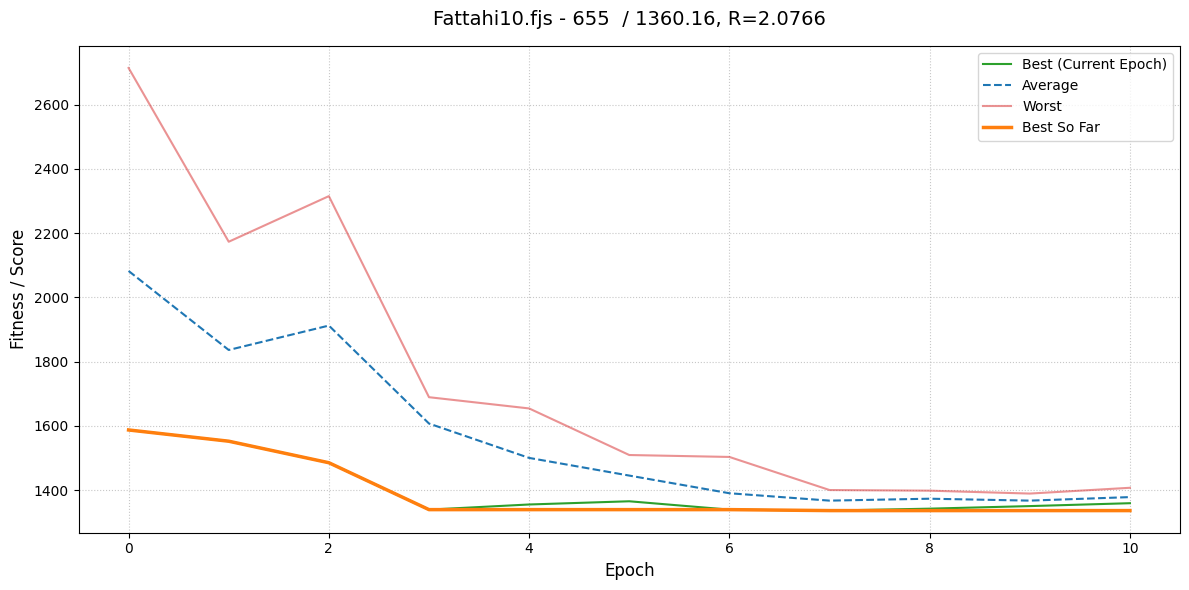

In [ ]:
plot_learning_progress(method.get_log_file_path(), instance_name=instance_name, c=c, robust_c=robust_c)

# Experiments

In [ ]:
def evaluate_method_with_params(params: MethodParams, encoding: Encoding):
    method = Method(params, encoding, uncertain_eval_function)
    best_indv = method.solve()
    best_solution = best_indv.get_representation()
    
    c = best_indv.get_internal_fitness()
    robust_c = uncertain_eval_function(best_indv)
    
    plot_fjsspw_gantt(*best_solution, encoding=encoding, instance_name=params.instance_name, c=c, robust_c=robust_c)
    plot_learning_progress(method.get_log_file_path(), instance_name=params.instance_name, c=c, robust_c=robust_c)

## generations=100, Pop=10, Indv_evals=3

In [ ]:
method_params_3 = MethodParams(
    generations=100,
    population_size=10,
    selection=Selections.ROULETTE,
    crossover=Crossovers.POX,
    mutation=Mutations.GENE_SWAP,
    fitness_fun_evals_per_indv=3,
    instance_name=instance_name,
)

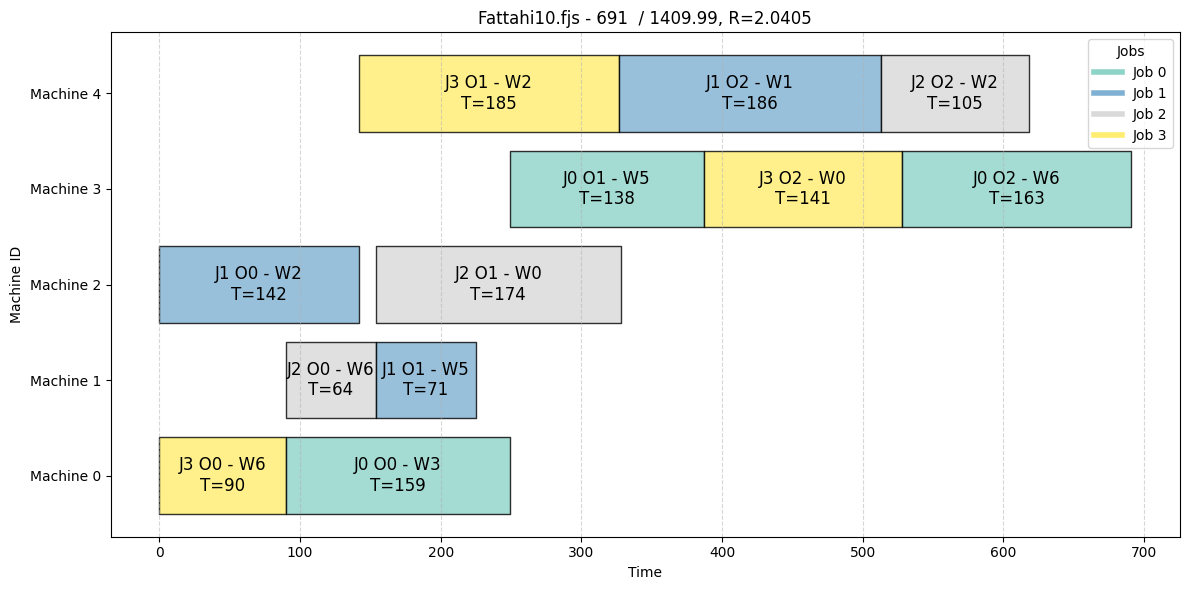

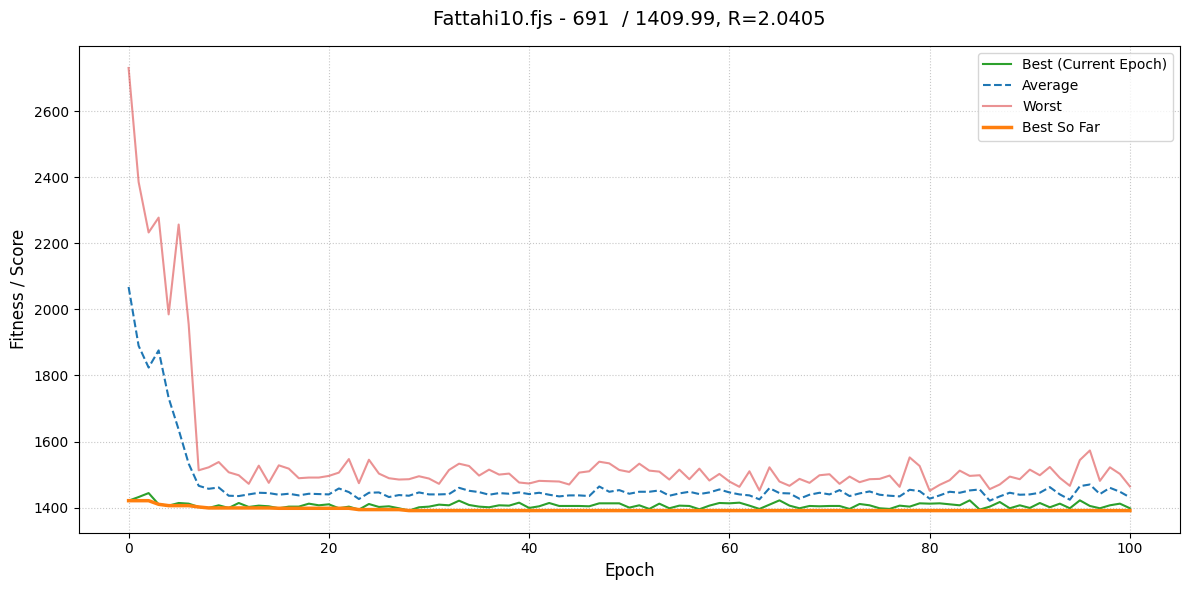

In [13]:
evaluate_method_with_params(method_params_3, encoding)

## generations=100, Pop=10, Indv_evals=5

In [ ]:
method_params_5 = MethodParams(
    generations=100,
    population_size=10,
    selection=Selections.ROULETTE,
    crossover=Crossovers.POX,
    mutation=Mutations.GENE_SWAP,
    fitness_fun_evals_per_indv=5,
    instance_name=instance_name,
)

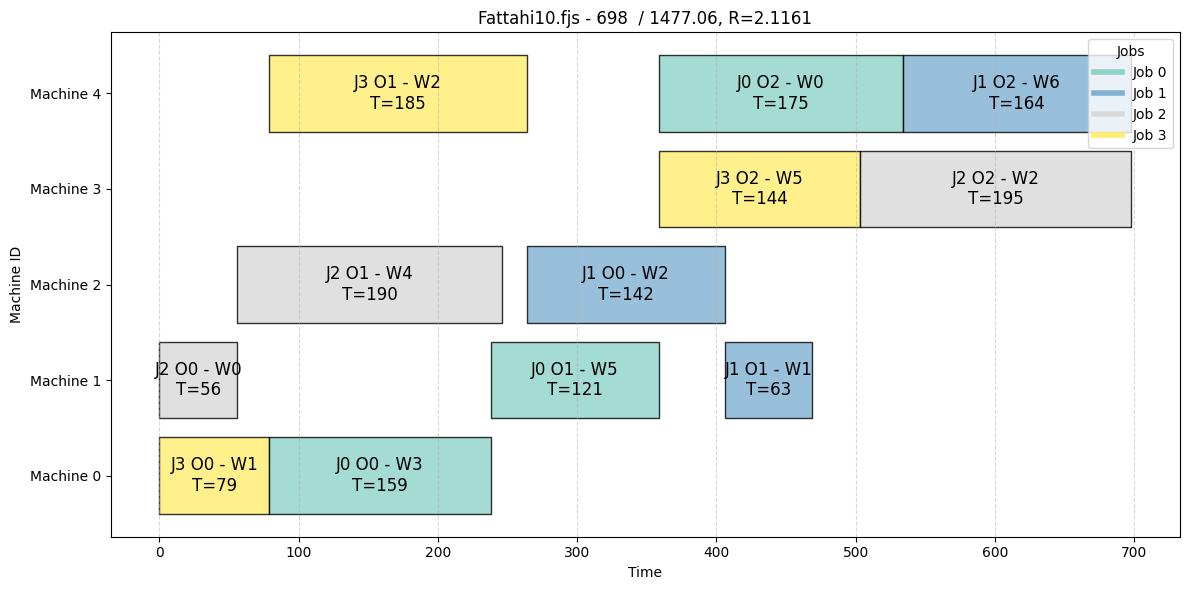

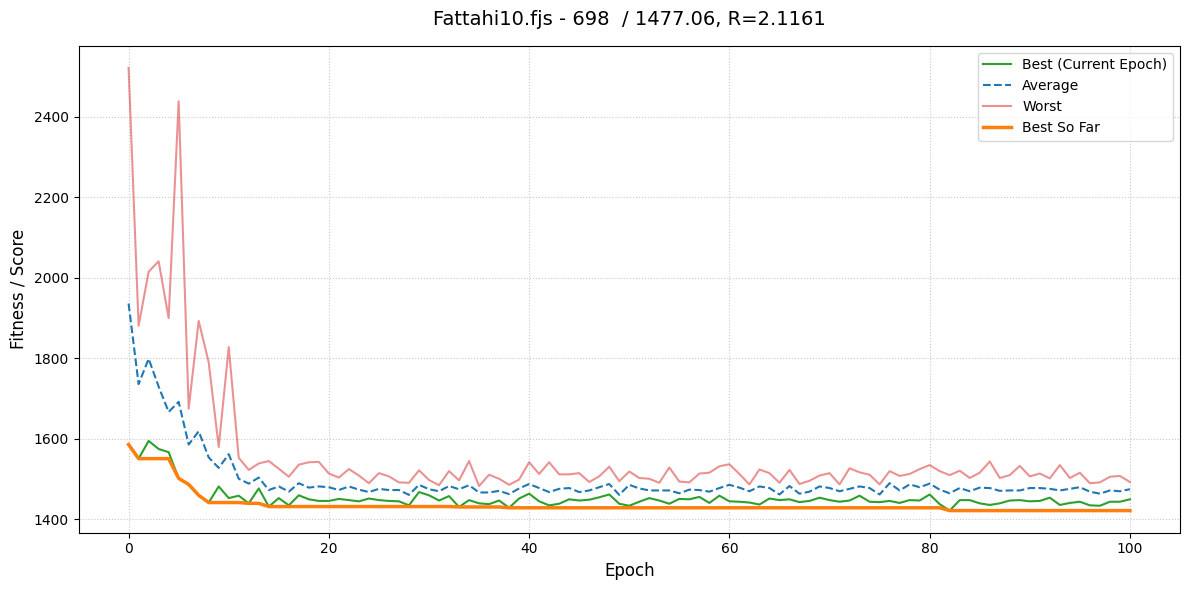

In [14]:
evaluate_method_with_params(method_params_5, encoding)

## generations=100, Pop=20, Indv_evals=3

In [ ]:
method_params_3_20 = MethodParams(
    generations=100,
    population_size=20,
    selection=Selections.ROULETTE,
    crossover=Crossovers.POX,
    mutation=Mutations.GENE_SWAP,
    fitness_fun_evals_per_indv=5,
    instance_name=instance_name,
)

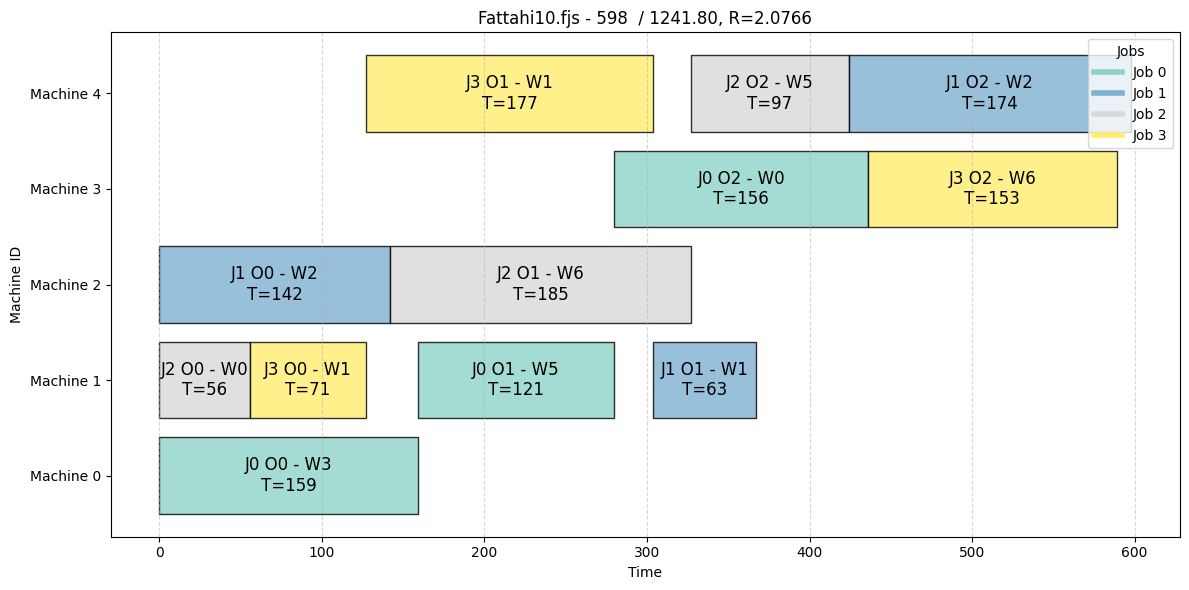

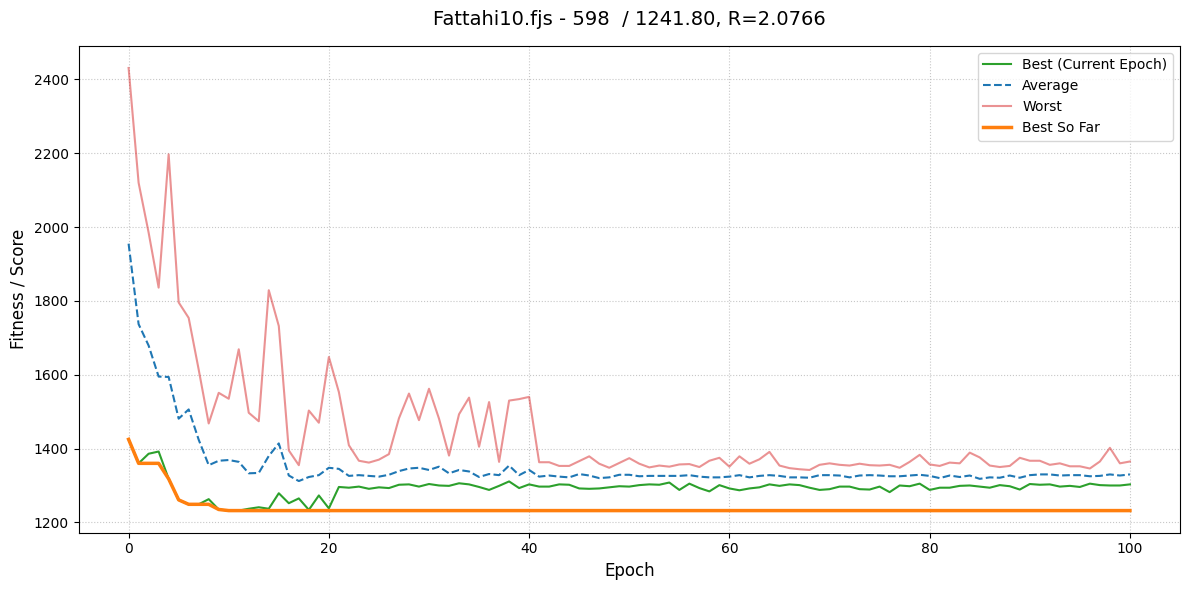

In [ ]:
evaluate_method_with_params(method_params_3_20, encoding)

## generations=100, Pop=25, Indv_evals=3

In [ ]:
method_params_3_25 = MethodParams(
    generations=100,
    population_size=20,
    selection=Selections.ROULETTE,
    crossover=Crossovers.POX,
    mutation=Mutations.GENE_SWAP,
    fitness_fun_evals_per_indv=5,
    instance_name=instance_name,
)

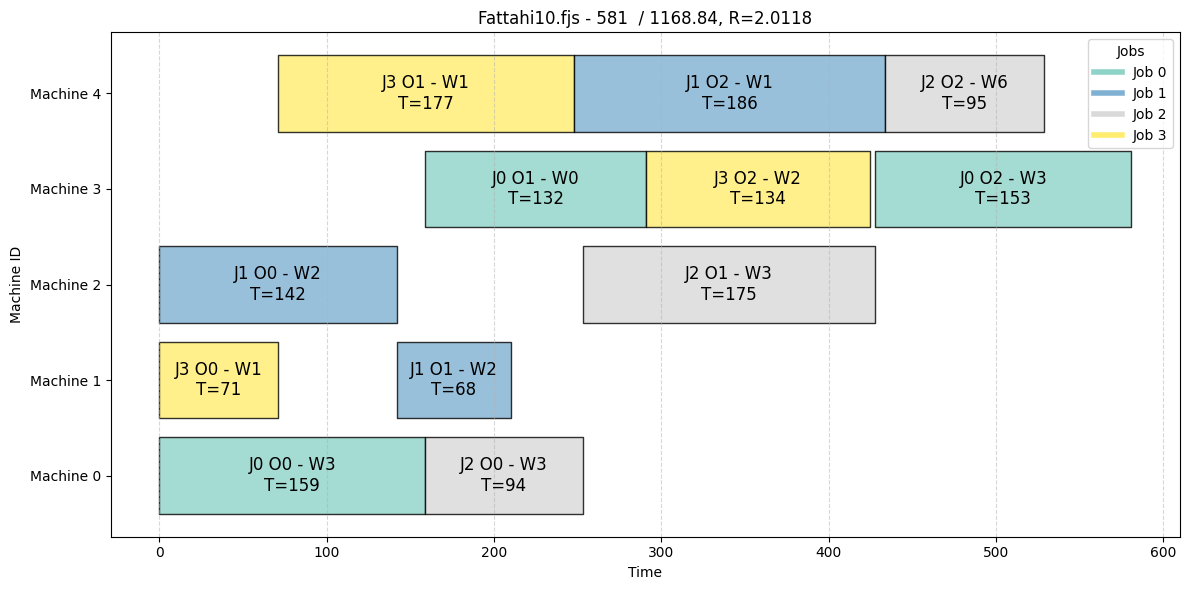

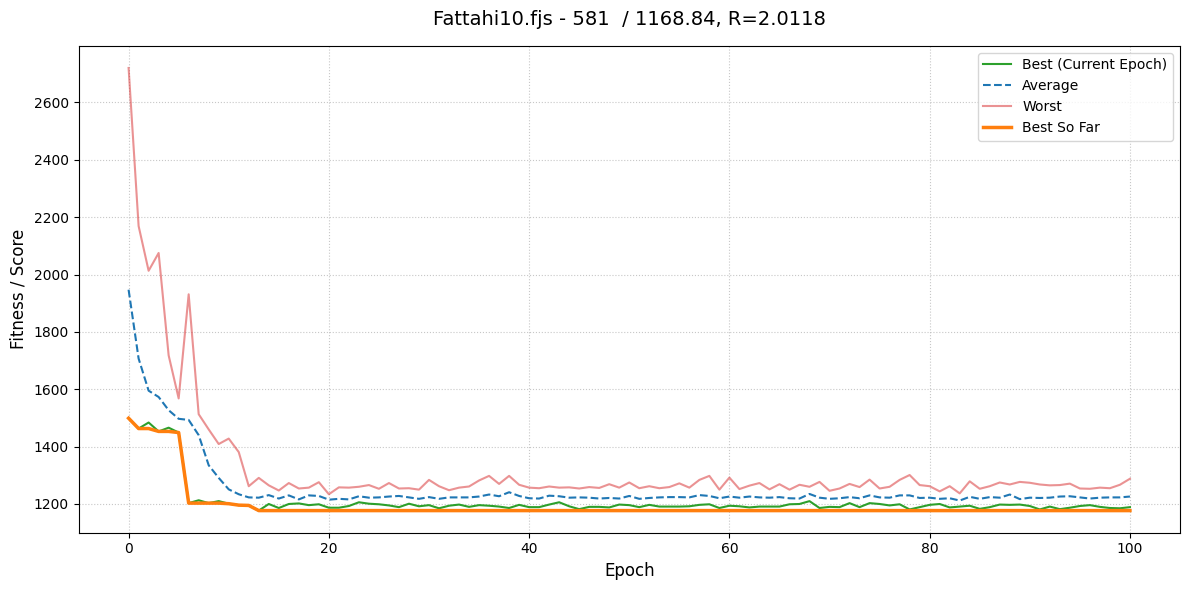

In [19]:
evaluate_method_with_params(method_params_3_25, encoding)